## Imports

In [2]:
import os
import json
import random
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from PIL import Image, UnidentifiedImageError
import numpy as np
from tensorflow.keras.preprocessing import image

### Load Dataset

In [3]:
# Paths
json_path = r"C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos.json"
image_dir = r"C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos"  

In [4]:
# Load metadata
df = pd.read_json(json_path, lines=True)  

# Construct full image paths
df["file_path"] = df["photo_id"].apply(lambda x: os.path.join(image_dir, f"{x}.jpg"))

# Filter only existing images
df = df[df["file_path"].apply(os.path.exists)]

# Filter out images that can't be opened (invalid images)
def is_valid_image(img_path):
    try:
        img = Image.open(img_path)
        img.verify()  
        return True
    except (UnidentifiedImageError, IOError):
        return False

# Filter out only valid images
df_valid_images = df[df["file_path"].apply(is_valid_image)]

print(f"Total valid images: {len(df_valid_images)}")

Total valid images: 199994


In [5]:
# Sample 30,000 valid images
df_sampled = df_valid_images.sample(n=30000, random_state=42)

print(f"Sampled {len(df_sampled)} images.")
print(df_sampled.head())

Sampled 30000 images.
                      photo_id             business_id  \
147732  042PS36S1ra1OCpcDSplfQ  v4lz71o76wWD8H15NsbZGA   
158909  gMzfampXD7M3viaLDZLfbg  caSFK6m6kbifsD9ZF7bCNw   
54973   waJSRfqQ957Iy8pb_nPwNg  9ouyziwYpSvJzlLFpukSgA   
49723   tLM6Y6ipHfbCB7VxUL0XbA  qWCREF22tkA-IfA1D9cNtg   
86301   4vo9NZ6swi8LqOjSsGkgyA  42tur3_5JgqOU-5KoY-zHQ   

                                                  caption    label  \
147732      Great selection of beer and chill atmosphere!   inside   
158909  Great picture this evening of Bourbon Street a...  outside   
54973                                                         food   
49723                                                       inside   
86301                                                      outside   

                                                file_path  
147732  C:\Users\JISNA\Desktop\sem 3\computer vision\Y...  
158909  C:\Users\JISNA\Desktop\sem 3\computer vision\Y...  
54973   C:\Users\JISNA\Deskt

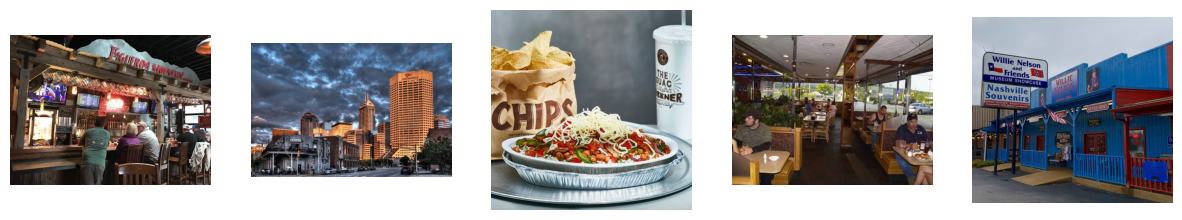

In [6]:
# Display some sample images
sample_images = df_sampled["file_path"].iloc[:5].tolist()

fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for ax, img_path in zip(axes, sample_images):
    img = cv2.imread(img_path)[..., ::-1]  # Convert BGR to RGB
    ax.imshow(img)
    ax.axis("off")
plt.show()


### Null check

In [7]:
print(df_sampled.isnull().sum())

photo_id       0
business_id    0
caption        0
label          0
file_path      0
dtype: int64


In [9]:
from torchvision import transforms

# Define Transformations
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize all images to 64x64
    transforms.ToTensor(),        # Convert to tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

In [11]:
from torch.utils.data import Dataset, DataLoader

# Define Dataset Class
class YelpDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["file_path"]
        img = Image.open(img_path).convert("RGB")  
        if self.transform:
            img = self.transform(img)
        return img

# Create DataLoader for Sampled Images
dataset = YelpDataset(df_sampled, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"Total batches: {len(dataloader)}")

Total batches: 469


In [12]:
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),  
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.ReLU()
        )
        
        self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, latent_dim)

        # Decoder
        self.decoder_fc = nn.Linear(latent_dim, 128 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Tanh()  
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = self.encoder(x).view(x.size(0), -1)
        mu, logvar = self.fc_mu(x), self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)
        x_reconstructed = self.decoder_fc(z).view(-1, 128, 8, 8)
        return self.decoder(x_reconstructed), mu, logvar


In [14]:
import torch
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE().to(device)

optimizer = optim.Adam(vae.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# Training Loop
num_epochs = 10
for epoch in range(num_epochs):
    for imgs in dataloader:
        imgs = imgs.to(device)
        
        optimizer.zero_grad()
        reconstructed, mu, logvar = vae(imgs)

        # Loss: Reconstruction + KL Divergence
        reconstruction_loss = loss_fn(reconstructed, imgs)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = reconstruction_loss + kl_loss

        loss.backward()
        optimizer.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [1/10], Loss: 0.3031
Epoch [2/10], Loss: 0.3319
Epoch [3/10], Loss: 0.2990
Epoch [4/10], Loss: 0.3331
Epoch [5/10], Loss: 0.3338
Epoch [6/10], Loss: 0.3328
Epoch [7/10], Loss: 0.2860
Epoch [8/10], Loss: 0.3075
Epoch [9/10], Loss: 0.3166
Epoch [10/10], Loss: 0.3213


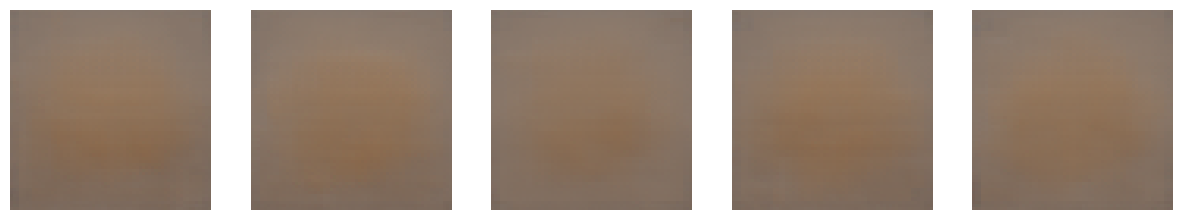

In [15]:
vae.eval()
with torch.no_grad():
    z = torch.randn(5, 128).to(device)
    generated_images = vae.decoder_fc(z).view(-1, 128, 8, 8)
    generated_images = vae.decoder(generated_images)

generated_images = generated_images.cpu().numpy().transpose(0, 2, 3, 1)

# Plot generated images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow((generated_images[i] + 1) / 2)  # Denormalize to [0,1]
    ax.axis("off")
plt.show()


In [36]:
# Training Loop
num_epochs = 50  # Updated to 50 epochs
for epoch in range(num_epochs):
    for imgs in dataloader:
        imgs = imgs.to(device)
        
        optimizer.zero_grad()
        reconstructed, mu, logvar = vae(imgs)
    
        # Loss: Reconstruction + KL Divergence
        reconstruction_loss = loss_fn(reconstructed, imgs)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = reconstruction_loss + kl_loss

        loss.backward()
        optimizer.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [1/50], Loss: 0.3193
Epoch [2/50], Loss: 0.3198
Epoch [3/50], Loss: 0.3075
Epoch [4/50], Loss: 0.2989
Epoch [5/50], Loss: 0.3119
Epoch [6/50], Loss: 0.3098
Epoch [7/50], Loss: 0.3334
Epoch [8/50], Loss: 0.2976
Epoch [9/50], Loss: 0.2880
Epoch [10/50], Loss: 0.2874
Epoch [11/50], Loss: 0.3332
Epoch [12/50], Loss: 0.2850
Epoch [13/50], Loss: 0.3128
Epoch [14/50], Loss: 0.3375
Epoch [15/50], Loss: 0.3148
Epoch [16/50], Loss: 0.2984
Epoch [17/50], Loss: 0.3108
Epoch [18/50], Loss: 0.3109
Epoch [19/50], Loss: 0.3049
Epoch [20/50], Loss: 0.3005
Epoch [21/50], Loss: 0.3045
Epoch [22/50], Loss: 0.3123
Epoch [23/50], Loss: 0.3365
Epoch [24/50], Loss: 0.3242
Epoch [25/50], Loss: 0.3059
Epoch [26/50], Loss: 0.3101
Epoch [27/50], Loss: 0.2909
Epoch [28/50], Loss: 0.3010
Epoch [29/50], Loss: 0.2817
Epoch [30/50], Loss: 0.3363
Epoch [31/50], Loss: 0.3494
Epoch [32/50], Loss: 0.3456
Epoch [33/50], Loss: 0.3112
Epoch [34/50], Loss: 0.3330
Epoch [35/50], Loss: 0.3112
Epoch [36/50], Loss: 0.3462
E

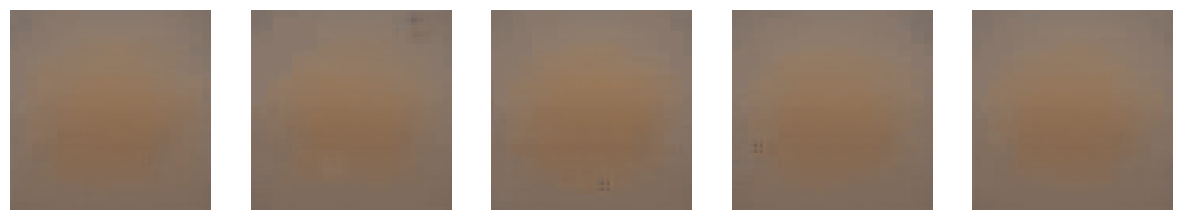

In [37]:
# Set model to evaluation mode
vae.eval()

# Generate new images
with torch.no_grad():
    z = torch.randn(5, 128).to(device)  # Assuming latent space size is 128
    generated_images = vae.decoder_fc(z).view(-1, 128, 8, 8)  # Adjust dimensions as per your model
    generated_images = vae.decoder(generated_images)

# Convert images to NumPy and adjust shape for visualization
generated_images = generated_images.cpu().numpy().transpose(0, 2, 3, 1)

# Plot generated images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow((generated_images[i] + 1) / 2)  # Denormalize to [0,1]
    ax.axis("off")
plt.show()


In [38]:
# Training Loop
num_epochs = 100 # Updated to 50 epochs
for epoch in range(num_epochs):
    for imgs in dataloader:
        imgs = imgs.to(device)
        
        optimizer.zero_grad()
        reconstructed, mu, logvar = vae(imgs)
    
        # Loss: Reconstruction + KL Divergence
        reconstruction_loss = loss_fn(reconstructed, imgs)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = reconstruction_loss + kl_loss

        loss.backward()
        optimizer.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [1/100], Loss: 0.2944
Epoch [2/100], Loss: 0.3062
Epoch [3/100], Loss: 0.2911
Epoch [4/100], Loss: 0.3004
Epoch [5/100], Loss: 0.3001
Epoch [6/100], Loss: 0.3029
Epoch [7/100], Loss: 0.3184
Epoch [8/100], Loss: 0.2933
Epoch [9/100], Loss: 0.3128
Epoch [10/100], Loss: 0.3217
Epoch [11/100], Loss: 0.3007
Epoch [12/100], Loss: 0.2740
Epoch [13/100], Loss: 0.3309
Epoch [14/100], Loss: 0.3183
Epoch [15/100], Loss: 0.3384
Epoch [16/100], Loss: 0.2937
Epoch [17/100], Loss: 0.2687
Epoch [18/100], Loss: 0.3119
Epoch [19/100], Loss: 0.2875
Epoch [20/100], Loss: 0.2999
Epoch [21/100], Loss: 0.2915
Epoch [22/100], Loss: 0.3061
Epoch [23/100], Loss: 0.3375
Epoch [24/100], Loss: 0.3316
Epoch [25/100], Loss: 0.3274
Epoch [26/100], Loss: 0.3352
Epoch [27/100], Loss: 0.3253
Epoch [28/100], Loss: 0.3326
Epoch [29/100], Loss: 0.3472
Epoch [30/100], Loss: 0.2958
Epoch [31/100], Loss: 0.3494
Epoch [32/100], Loss: 0.3087
Epoch [33/100], Loss: 0.3206
Epoch [34/100], Loss: 0.2943
Epoch [35/100], Loss: 0

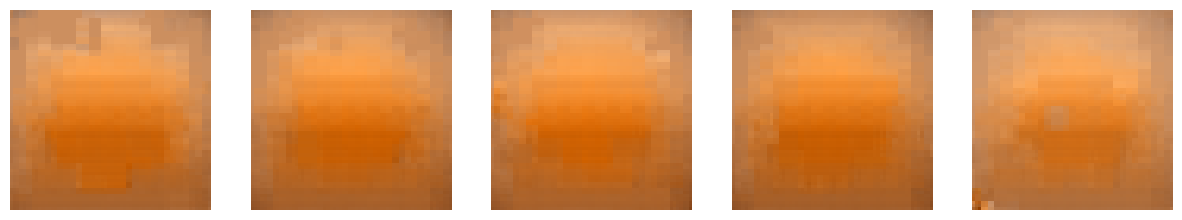

In [41]:
vae.eval()  # Set VAE to evaluation mode
with torch.no_grad():
    z = torch.randn(5, 128).to(device)  # Sample random latent vectors
    generated_images = vae.decoder_fc(z).view(-1, 128, 8, 8)
    generated_images = vae.decoder(generated_images)

generated_images = generated_images.cpu().numpy().transpose(0, 2, 3, 1)  # Convert to NumPy for visualization

# Plot generated images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow((generated_images[i] - generated_images[i].min()) / (generated_images[i].max() - generated_images[i].min()))  # Normalize to [0,1]
    ax.axis("off")
plt.show()


In [47]:
!pip install torch torchvision numpy scipy tqdm

In [53]:
def calculate_inception_score(images, batch_size=32, splits=10):
    N = len(images)
    
    # Modify the batch size if there are fewer images than the batch size
    if N <= batch_size:
        batch_size = N  # Use all images in one batch
    
    assert N > 0, "Number of images must be greater than 0"
    
    # Inception Model to get the probability distribution for each image
    def get_inception_probs(images):
        images = images.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
        with torch.no_grad():
            preds = inception_model(images)
            return F.softmax(preds, dim=1)
    
    # Split images into batches
    dataloader = torch.utils.data.DataLoader(images, batch_size=batch_size)
    all_preds = []
    for batch in tqdm(dataloader, desc="Calculating Inception Score"):
        all_preds.append(get_inception_probs(batch))
    
    all_preds = torch.cat(all_preds, dim=0).cpu().numpy()
    
    # Compute IS score
    scores = []
    for i in range(splits):
        part = all_preds[i * (N // splits):(i + 1) * (N // splits)]
        py = np.mean(part, axis=0)
        scores.append(np.exp(np.mean(np.sum(part * (np.log(part) - np.log(py)), axis=1))))
    return np.mean(scores), np.std(scores)